<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/VAR_GPRD_OIL_GAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fredapi

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
import scipy.stats as stats
from fredapi import Fred
from google.colab import userdata
import sys
from google.colab import drive
fred = Fred(api_key=userdata.get('fredapi_key'))
data_futures = pd.read_csv(userdata.get('data_path'))

In [ ]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["symbol"].isin(["ES", "CL", 'C', 'GC', 'NG'])].sort_values(["symbol", "date"])

# 2. Compute daily percentage log returns: r_t = 100 * ln(Close_t / Close_{t-1})
# Multiplying by 100 is standard practice to prevent tiny decimals from destabilizing MLE optimizers
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)
# 3. Scale Realized Variance if needed (match the scale of returns^2)
# If returns are in %, variance should be scaled by 100^2 = 10,000
data["log_rv_scaled"] = np.log(data["rk"] * 10000)

# 4. Pivot into a clean wide DataFrame aligned on Date
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv_scaled", "rk"],
)

# Flatten MultiIndex columns (e.g., ret_ES, rv_CL)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]

# Drop trading calendar mismatches / initial NaNs
df = df.dropna()

In [ ]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-67.2516,0.0000e+00,0.0787,0.1,Stationary
ret_CL,-10.6288,5.2784e-19,0.0373,0.1,Stationary
ret_ES,-14.9578,1.2527e-27,0.0222,0.1,Stationary
ret_GC,-65.8138,0.0000e+00,0.3073,0.1,Stationary
ret_NG,-68.8376,0.0000e+00,0.0282,0.1,Stationary


In [ ]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "scaled" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv_scaled_C,-6.5968,6.8922e-09,1.2459,0.0100,Contradictory / Structural Break
log_rv_scaled_CL,-5.0090,2.1304e-05,1.2909,0.0100,Contradictory / Structural Break
log_rv_scaled_ES,-6.1398,8.0244e-08,0.3825,0.0847,Stationary
log_rv_scaled_GC,-5.8203,4.1981e-07,0.8519,0.0100,Contradictory / Structural Break
log_rv_scaled_NG,-4.5309,1.7285e-04,3.0578,0.0100,Contradictory / Structural Break


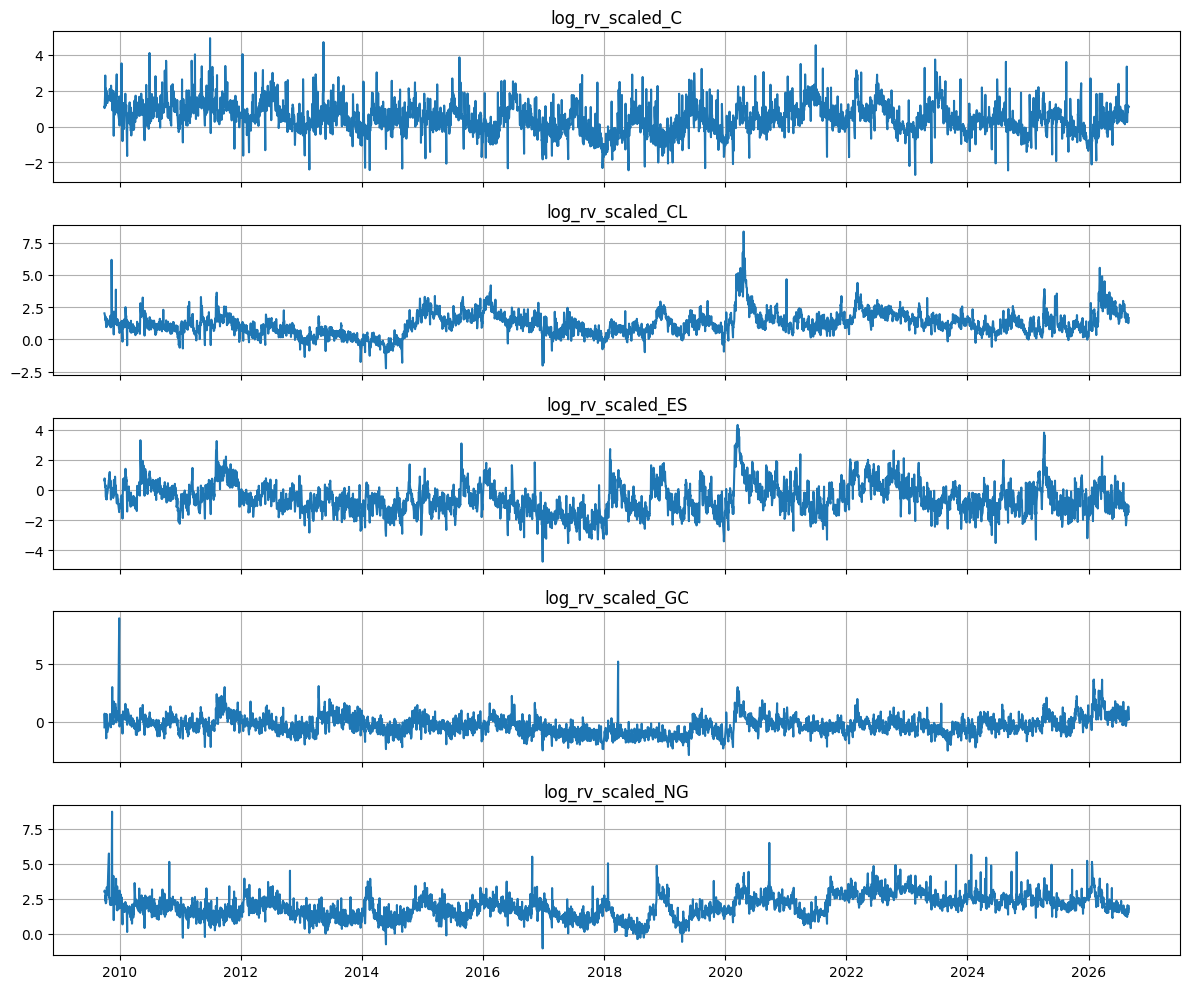

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "scaled" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#4. Model Selection
data = df[[col for col in df.columns if "scaled" in col]].copy()

# Refit standard model
model = VAR(data)

# model = VAR(endog=data)
# Evaluate lags 1 through 15
lag_order = model.select_order(maxlags=30)
print(lag_order.summary())

# Choose lag by AIC (more flexible) or BIC (more parsimonious)
optimal_lag = lag_order.bic
print(f"Optimal lag according to bic: {optimal_lag}")

# Fit the VAR model with the selected lag
results = model.fit(optimal_lag)
total_coefs = results.params.size
print(f"Total regression coefficients: {total_coefs}")

print(results.summary())



# # Does GPR predict Oil returns?
# gc_oil = results.test_causality('OIL', ['GPRD'], kind='f')
# print("Granger Causality (GPR -> Oil):")
# print(gc_oil.summary())

# # Does GPR predict Gas returns?
# gc_gas = results.test_causality('GAS', ['GPRD'], kind='f')
# print("\nGranger Causality (GPR -> Gas):")
# print(gc_gas.summary())




/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.471      -2.464     0.08450      -2.468
1       -6.629      -6.584    0.001322      -6.613
2       -7.087      -7.006   0.0008356      -7.058
3       -7.285      -7.166   0.0006859      -7.243
4       -7.388      -7.232   0.0006185      -7.333
5       -7.486     -7.293*   0.0005606      -7.418
6       -7.500      -7.270   0.0005530      -7.419
7       -7.513      -7.246   0.0005458      -7.419
8       -7.529      -7.224   0.0005372      -7.422
9       -7.551      -7.209   0.0005257      -7.430
10      -7.564      -7.186   0.0005186     -7.431*
11      -7.563      -7.147   0.0005192      -7.416
12      -7.565      -7.111   0.0005185      -7.404
13      -7.565      -7.075   0.0005183      -7.392
14     -7.573*      -7.045  0.0005144*      -7.386
15      -7.572      -7.008   0.0005145      -7.373
16      -7.566      -6.964   0.

In [ ]:
df.columns

Index(['close_price_C', 'close_price_CL', 'close_price_ES', 'ret_C', 'ret_CL',
       'ret_ES', 'log_rv_scaled_C', 'log_rv_scaled_CL', 'log_rv_scaled_ES',
       'rk_C', 'rk_CL', 'rk_ES'],
      dtype='object')

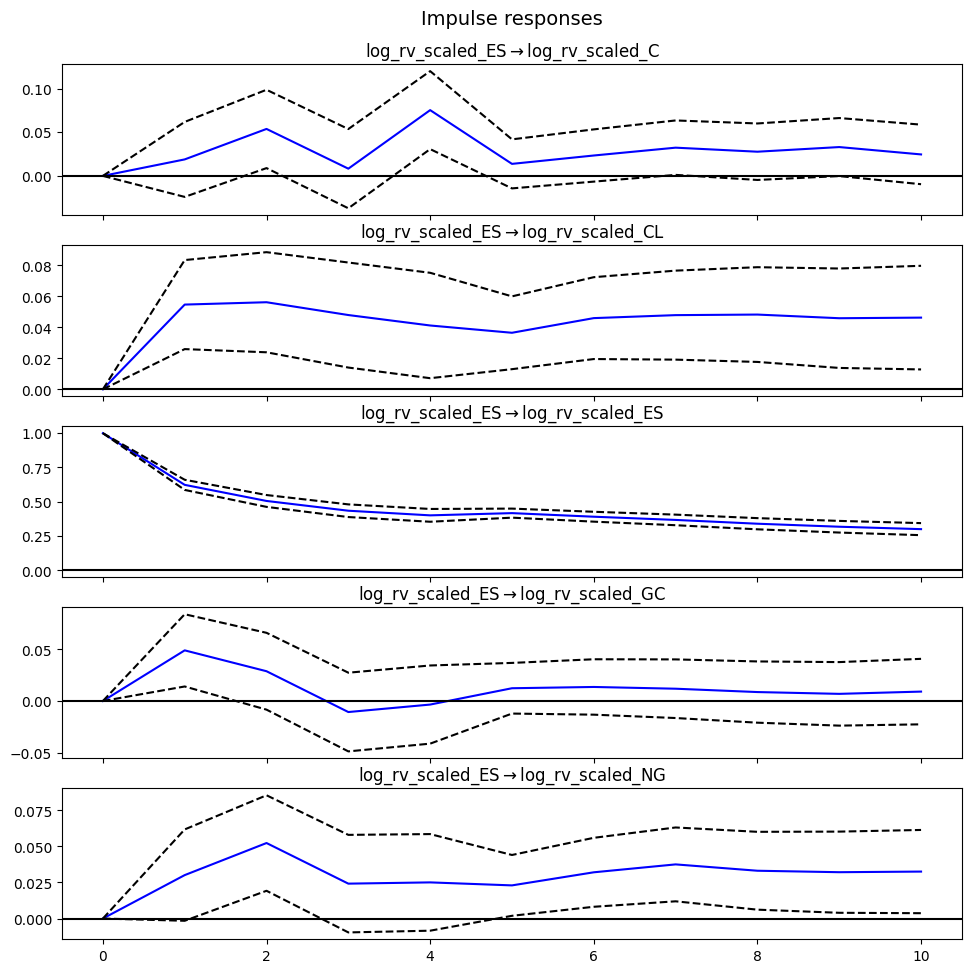

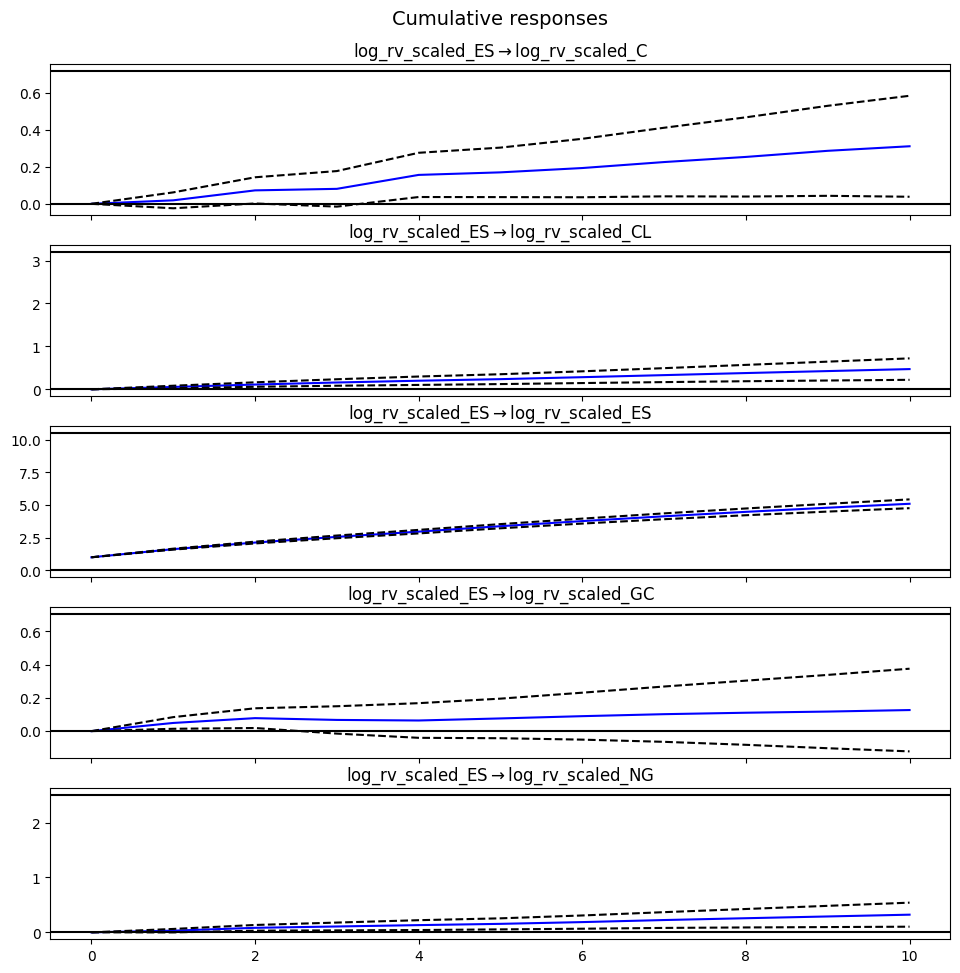

In [ ]:
# Compute orthogonalized IRFs (default uses Cholesky ordering based on DataFrame column order)
irf = results.irf(periods=10)

# Plot responses to a GPR shock
fig = irf.plot(impulse='log_rv_scaled_ES')
plt.show()

# Cumulative IRF (to see net directional impact over time)
fig_cum = irf.plot_cum_effects(impulse='log_rv_scaled_ES')
plt.show()

In [ ]:
fevd = results.fevd(10)
print(fevd.summary())
# fevd.plot()
# plt.show()

FEVD for log_rv_scaled_C
     log_rv_scaled_C  log_rv_scaled_CL  log_rv_scaled_ES  log_rv_scaled_GC  log_rv_scaled_NG
0           1.000000          0.000000          0.000000          0.000000          0.000000
1           0.998769          0.000104          0.000355          0.000279          0.000494
2           0.994477          0.000249          0.001105          0.000430          0.003738
3           0.993277          0.000748          0.001230          0.000851          0.003894
4           0.986817          0.000706          0.003678          0.000948          0.007851
5           0.987089          0.000706          0.003693          0.001169          0.007343
6           0.986329          0.000691          0.003936          0.001379          0.007665
7           0.984812          0.000675          0.004376          0.001553          0.008584
8           0.983800          0.000681          0.004762          0.001799          0.008958
9           0.982218          0.000666       

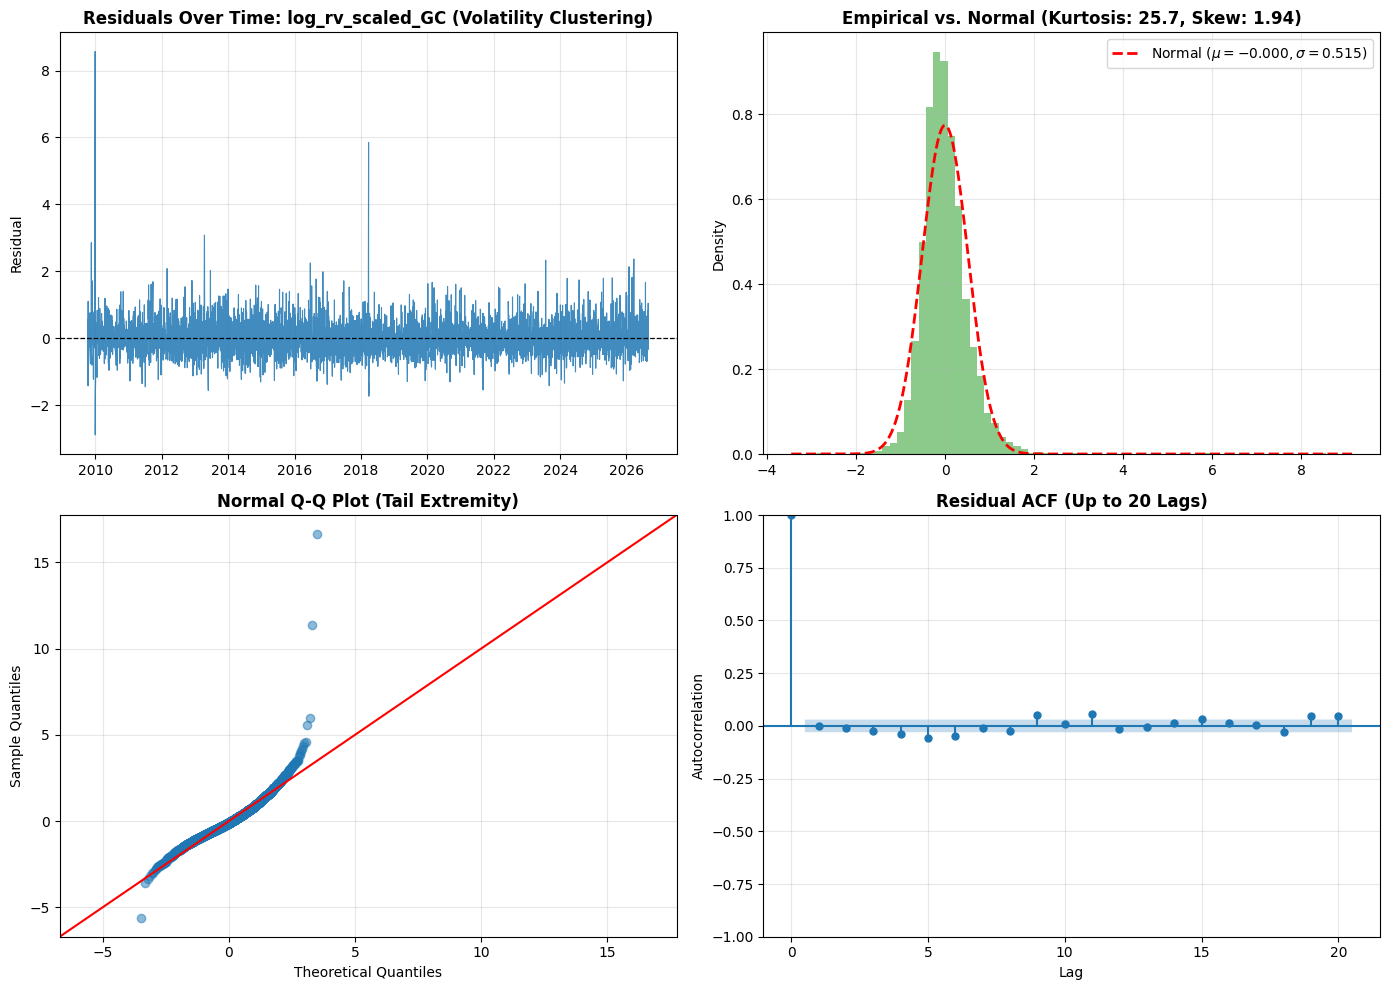

In [ ]:
gf.plot_var_residual_diagnostics(results, 'log_rv_scaled_GC')

In [ ]:
# Find the exact date of the worst drop
worst_date = var_df['GAS_RET'].idxmin()
print("Worst outlier date:", worst_date)
print("Outlier value:", var_df.loc[worst_date, 'GAS_RET'])

# Check the top 5 most extreme absolute swings
print("\nTop 5 absolute swings in GAS_RET:")
print(var_df['GAS_RET'].abs().nlargest(5))

Worst outlier date: 2024-01-16 00:00:00
Outlier value: -1.401561833250679

Top 5 absolute swings in GAS_RET:
2024-01-12    1.432814
2024-01-16    1.401562
2026-01-23    1.294304
2021-02-18    1.025103
2025-01-17    0.829871
Name: GAS_RET, dtype: float64
